---
## Produce Plots from Saved Data

In [2]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [3]:
def read_lists_from_file(file_path):
    """Reads lists from a text file and returns them as a list of lists."""
    list_of_lists = []
    with open(file_path, 'r') as file:
        for line in file:
            cleaned_line = line.strip().strip('[]')
            string_elements = cleaned_line.split(',')
            
            # Try converting elements to int, float, or keep as string if conversion fails
            elements = []
            for s in string_elements:
                s = s.strip().strip("'").strip()
                try:
                    elements.append(int(s))
                except ValueError:
                    try:
                        elements.append(float(s))
                    except ValueError:
                        elements.append(s)
            
            if elements:
                list_of_lists.append(elements)
    return list_of_lists


In [4]:
def read_norms_from_pth(path, hidden_dim=128, k=10):
    sumNorms = []
    norms = []
    for m in range(k):
        W1 = torch.load("weights/he_identity_adam/dim=%s_layer=" % hidden_dim + "0_k=%s.pth" % m)['linear.weight']
        b1 = torch.load("weights/he_identity_adam/dim=%s_layer=" % hidden_dim + "0_k=%s.pth" % m)['linear.bias']
        W2 = torch.load("weights/he_identity_adam/dim=%s_layer=" % hidden_dim + "1_k=%s.pth" % m)['linear.weight']
        b2 = torch.load("weights/he_identity_adam/dim=%s_layer=" % hidden_dim + "1_k=%s.pth" % m)['linear.bias']
        currNorms = [np.linalg.norm(W1), np.linalg.norm(b1), np.linalg.norm(W2), np.linalg.norm(b2)]
        norms.append(currNorms)
        sumNorms.append(np.sum(np.square(currNorms)))

    return norms, sumNorms

---
Uniform Mapping

(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)
(40, 1)


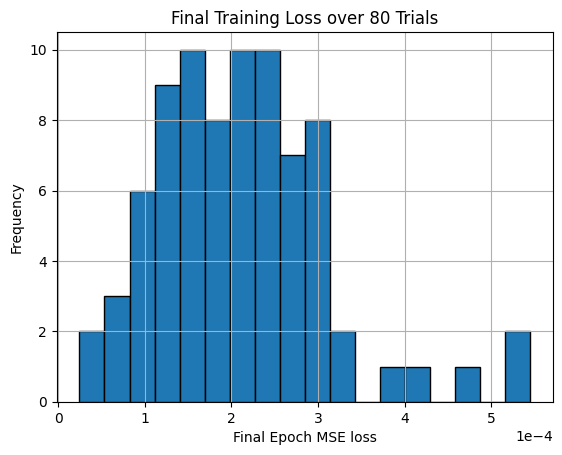

In [102]:
finalTrainLoss = []

for i in range(80):
    folder = 'outputs/uniformNorms/run_' + str(i)
    file_list = np.array(read_lists_from_file(folder + "/finalTrain.txt"))
    print(file_list.shape)
    final_train = [float(s[0].split(":")[1]) for s in file_list[[4*j+3 for j in range(10)]]]
    finalTrainLoss.append(np.mean(final_train))

plt.figure()
counts, bins, patches = plt.hist(finalTrainLoss, bins=18, histtype='bar', alpha=1, edgecolor='black')
plt.title('Final Training Loss over 80 Trials')
plt.ylabel('Frequency')
plt.xlabel('Final Epoch MSE loss')
plt.ticklabel_format(axis='x', style='sci', scilimits=(-3,3))

plt.grid(True)
plt.savefig("outputs/uniformNorms/hist_finalTrain.jpg", bbox_inches="tight")
plt.show()

80
10


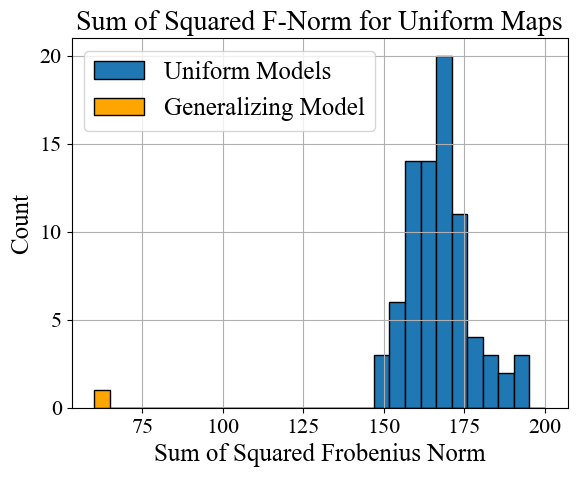

In [22]:
plt.rcParams.update({
    'font.size': 16,             # base font size
    'axes.titlesize': 24,        # title size
    'axes.labelsize': 20,        # x/y label size
    'xtick.labelsize': 16,       # x tick label size
    'ytick.labelsize': 16,       # y tick label size
    'legend.fontsize': 20,       # legend size
    'font.family': 'Times New Roman'
})

folder='outputs/uniformNorms'
folderIdentity='weights/he_identity_adam'

norm_list = []
avgNorm_list = []

for i in range(80):
    folder_run='outputs/uniformNorms/run_' + str(i)
    curr_norm = np.array(read_lists_from_file(folder_run + "/norms.txt"))
    avg_norm = np.mean(curr_norm, axis=0)
    norm_list.append(curr_norm)
    avgNorm_list.append(avg_norm)

print(len(norm_list))
print(len(norm_list[0]))

_, identitySumNorms = read_norms_from_pth(folderIdentity)
avgIdSumNorm = np.mean(identitySumNorms)

sumNorms = []
for i in range(80): 
    sumNorms.append(np.sum(np.square(avgNorm_list[i])))

plt.figure()
bins = np.linspace(60, 200, 30)
counts, bins, patches = plt.hist(sumNorms, bins=bins, label='Uniform Models', edgecolor='black')
countsId, binsId, patchesId = plt.hist(avgIdSumNorm, bins=bins, color='orange', label='Generalizing Model', edgecolor='black')
#patchesId[0].set_facecolor('orange')

# Add labels and title
plt.xlabel('Sum of Squared Frobenius Norm')
plt.ylabel('Count')
plt.title('Sum of Squared F-Norm for Uniform Maps')
plt.ticklabel_format(axis='x', style='sci', scilimits=(-3,3))
plt.legend()

plt.grid(True)
plt.savefig(folder + "/plot_sumNorms.png", bbox_inches="tight")
plt.show()
    

---
Permute Norms

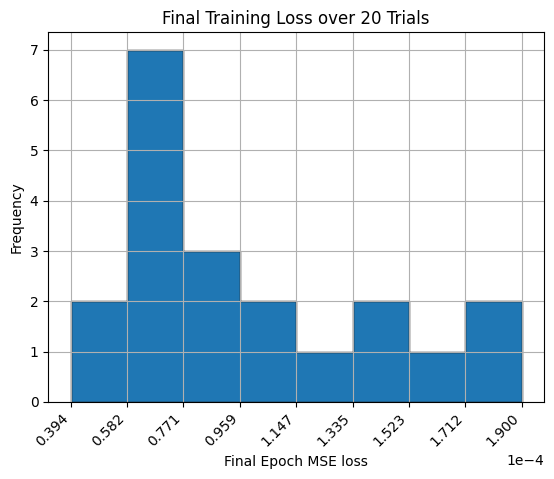

In [28]:
finalTrainLoss = []

for i in range(20):
    folder = 'outputs/permuteNorms/run_' + str(i)
    file_list = read_lists_from_file(folder + "/finalTrain.txt")
    final_train = [float(s[-1].split(":")[1]) for s in read_lists_from_file(folder + "/finalTrain.txt")]
    finalTrainLoss.append(np.mean(final_train))

plt.figure()
counts, bins, patches = plt.hist(finalTrainLoss, bins=8, histtype='stepfilled', alpha=1, edgecolor='black')
plt.title('Final Training Loss over 20 Trials')
plt.ylabel('Frequency')
plt.xlabel('Final Epoch MSE loss')
plt.xticks(bins, rotation=45, ha='right')
plt.ticklabel_format(axis='x', style='sci', scilimits=(-3,3))

plt.grid(True)
plt.savefig("outputs/permuteNorms/hist_finalTrain.jpg", bbox_inches="tight")
plt.show()


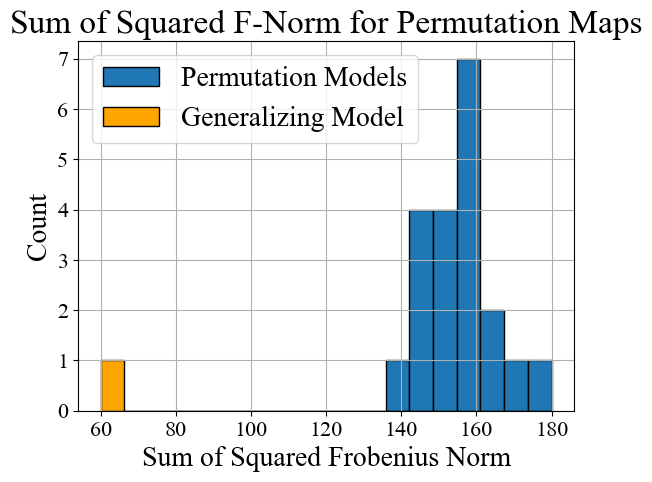

In [24]:
plt.rcParams.update({
    'font.size': 16,             # base font size
    'axes.titlesize': 24,        # title size
    'axes.labelsize': 20,        # x/y label size
    'xtick.labelsize': 16,       # x tick label size
    'ytick.labelsize': 16,       # y tick label size
    'legend.fontsize': 20,       # legend size
    'font.family': 'Times New Roman'
})

folder='outputs/permuteNorms'
folderIdentity='weights/he_identity_adam'

norm_list = []
avgNorm_list = []

for i in range(20):
    folder_run = folder + '/run_' + str(i)
    curr_norm = np.array(read_lists_from_file(folder_run + "/norms.txt"))
    avg_norm = np.mean(curr_norm, axis=0)
    norm_list.append(curr_norm)
    avgNorm_list.append(avg_norm)

_, identitySumNorms = read_norms_from_pth(folderIdentity)
avgIdSumNorm = np.mean(identitySumNorms)


sumNorms = []
for i in range(20): 
    sumNorms.append(np.sum(np.square(avgNorm_list[i])))

plt.figure()
bins = np.linspace(60, 180, 20)
counts, bins, patches = plt.hist(sumNorms, bins=bins, label='Permutation Models', edgecolor='black')
countsId, binsId, patchesId = plt.hist(avgIdSumNorm, bins=bins, color='orange', label='Generalizing Model', edgecolor='black')
#patchesId[0].set_facecolor('orange')

# Add labels and title
plt.xlabel('Sum of Squared Frobenius Norm')
plt.ylabel('Count')
plt.title('Sum of Squared F-Norm for Permutation Maps')
plt.ticklabel_format(axis='x', style='sci', scilimits=(-3,3))
plt.legend()

plt.grid(True)
plt.savefig(folder + "/plot_sumNorms.png", bbox_inches="tight")
plt.show()
    

---
Interpolate Norms

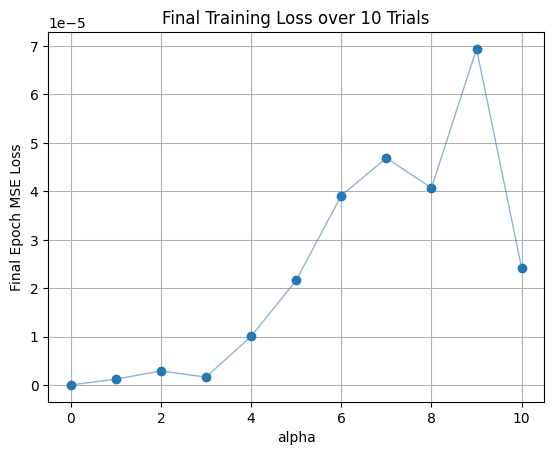

In [66]:
finalTrainLoss = []

for i in range(11):
    folder = 'outputs/interpolateNorms/run_' + str(i)
    file_list = read_lists_from_file(folder + "/finalTrain.txt")
    final_train = [float(s[-1].split(":")[1]) for s in read_lists_from_file(folder + "/finalTrain.txt")]
    finalTrainLoss.append(np.mean(final_train))

plt.figure()
#counts, bins, patches = plt.hist(finalTrainLoss, bins=5, histtype='stepfilled', alpha=1, edgecolor='black')
plt.plot(range(11), finalTrainLoss, 'o', alpha=1)
plt.plot(range(11), finalTrainLoss, '-', color='steelBlue', linewidth=1, alpha=0.6)
plt.title('Final Training Loss over 10 Trials')
plt.ylabel('Final Epoch MSE Loss')
plt.xlabel('alpha')

plt.grid(True)
plt.savefig("outputs/interpolateNorms/hist_finalTrain.jpg", bbox_inches="tight")
plt.show()

(4,)
(4,)
(4,)
(4,)
(4,)
(4,)
(4,)
(4,)
(4,)
(4,)
(4,)


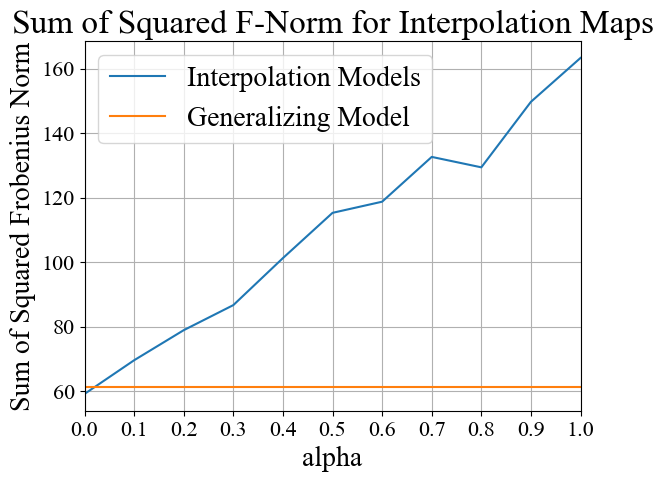

In [25]:
plt.rcParams.update({
    'font.size': 16,             # base font size
    'axes.titlesize': 24,        # title size
    'axes.labelsize': 20,        # x/y label size
    'xtick.labelsize': 16,       # x tick label size
    'ytick.labelsize': 16,       # y tick label size
    'legend.fontsize': 20,       # legend size
    'font.family': 'Times New Roman'
})


folder='outputs/interpolateNorms'
folderIdentity='weights/he_identity_adam'

norm_list = []
avgNorm_list = []

for i in range(11):
    folder_run = folder + '/run_' + str(i)
    curr_norm = np.array(read_lists_from_file(folder_run + "/norms.txt"))
    avg_norm = np.mean(curr_norm, axis=0)
    norm_list.append(curr_norm)
    print(avg_norm.shape)
    avgNorm_list.append(avg_norm)

_, identitySumNorms = read_norms_from_pth(folderIdentity)
avgIdSumNorm = np.mean(identitySumNorms)

sumNorms = []
for i in range(11): 
    sumNorms.append(np.sum(np.square(avgNorm_list[i])))

plt.figure()
alphas = np.arange(0, 1.1, 0.1)
plt.plot(alphas, sumNorms)
plt.plot(alphas, [avgIdSumNorm for _ in alphas])
plt.xlabel("alpha")
plt.ylabel("Sum of Squared Frobenius Norm")
plt.title("Sum of Squared F-Norm for Interpolation Maps")
plt.legend(["Interpolation Models", "Generalizing Model"])
plt.xticks(alphas)
plt.grid(True)
plt.xlim(left=0, right=1)
plt.savefig(folder + "/plot_sumNorms.png", bbox_inches="tight")
plt.show()
    

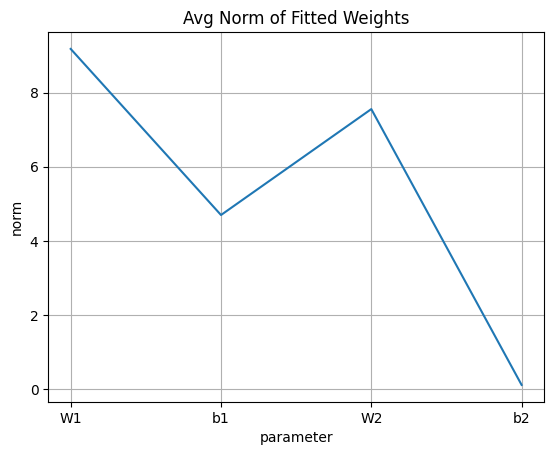

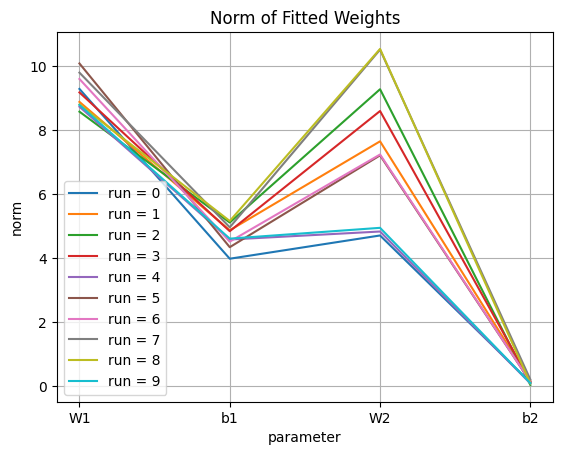

In [ ]:
folder='outputs/interpolateNorms'

plt.figure()
for i in range(10, 11): 
    plt.plot(avgNorm_list[i])
    #plt.legend(["run = " + str(i) for i in range(11)])
    plt.xlabel("parameter")
    plt.ylabel("norm")
    plt.title("Avg Norm of Fitted Weights")
    plt.xticks(range(4), ['W1', 'b1', 'W2', 'b2'])
    plt.grid(True)
    plt.savefig(folder + f"/run_{i}/plot_avgNorms.jpg", bbox_inches="tight")
    plt.show()

    for j in range(10):
        plt.plot(norm_list[i][j])
    plt.legend(["run = " + str(i) for i in range(10)])
    plt.xlabel("parameter")
    plt.ylabel("norm")
    plt.title("Norm of Fitted Weights")
    plt.xticks(range(4), ['W1', 'b1', 'W2', 'b2'])
    plt.grid(True)
    plt.savefig(folder + f"/run_{i}/plot_norms.jpg", bbox_inches="tight")
    